# Model training and evaluation

Baseline (median per airport) vs LightGBM, evaluated on the two time-based validation folds from `src/validation.py` -- January 2025 and July 2025, standing in for the real ranking months (January and July 2026). See `docs/plan.md` for the full sequence.

This notebook only orchestrates and plots -- the actual training logic lives in `src/train.py`, `src/train_lgbm.py`, `src/features.py`, and `src/validation.py`, so there is one source of truth for how the model is built, not two.

In [1]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from db import connect_clean
from features import FEATURE_COLUMNS
from validation import FOLDS, load_fold, rmse, rmse_by_airport
from train_lgbm import train_on_fold

con = connect_clean()
medians = pl.read_parquet('../data/models/baseline_medians.parquet')
baseline_lookup = medians.filter(pl.col('monitored_airport') != '__global__').select('monitored_airport', 'prediction')

## Run both folds

For each fold: compute the baseline's RMSE (Root Mean Square Error), train a LightGBM model via `train_on_fold`, and keep everything needed to plot below.

In [2]:
results = {}

for fold_name in FOLDS:
    fold = load_fold(con, fold_name)

    baseline_val = fold.val.join(baseline_lookup, on='monitored_airport', how='left')
    baseline_preds = baseline_val['prediction']
    baseline_overall = rmse(fold.val['TAXITIME_SEC_mvt'], baseline_preds)
    baseline_by_airport = rmse_by_airport(fold.val, baseline_preds).sort('monitored_airport')

    booster, lgbm_overall, fold2, lgbm_preds = train_on_fold(con, fold_name)
    lgbm_by_airport = rmse_by_airport(fold2.val, lgbm_preds).sort('monitored_airport')

    importance = pl.DataFrame({
        'feature': FEATURE_COLUMNS,
        'gain': booster.feature_importance(importance_type='gain'),
    }).sort('gain', descending=True)

    results[fold_name] = {
        'baseline_overall': baseline_overall,
        'lgbm_overall': lgbm_overall,
        'baseline_by_airport': baseline_by_airport,
        'lgbm_by_airport': lgbm_by_airport,
        'importance': importance,
        'val': fold2.val,
        'lgbm_preds': lgbm_preds,
    }

    print(f"{fold_name}: baseline RMSE={baseline_overall:.1f}s  LightGBM RMSE={lgbm_overall:.1f}s  "
          f"improvement={100*(baseline_overall-lgbm_overall)/baseline_overall:.1f}%")

jan: baseline RMSE=586.7s  LightGBM RMSE=542.9s  improvement=7.5%
jul: baseline RMSE=723.8s  LightGBM RMSE=631.2s  improvement=12.8%


## RMSE by airport: baseline vs LightGBM

Rome-Fiumicino (LIRF) is the clear outlier in both folds -- correlated with the flight-match-failure rows flagged during data cleaning (`flag_flt_unmatched`, see `docs/data_dictionary.md`).

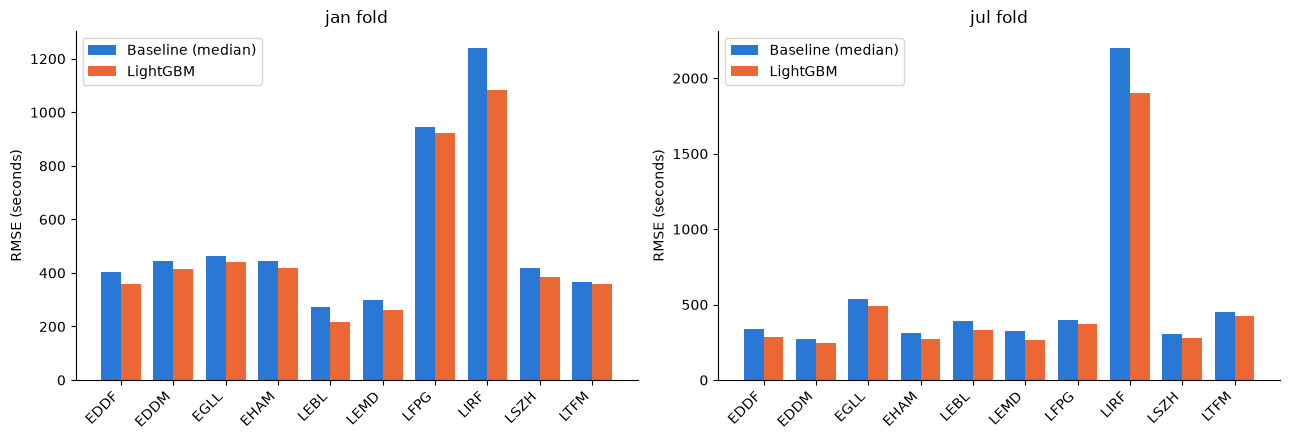

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, fold_name in zip(axes, FOLDS):
    r = results[fold_name]
    airports = r['baseline_by_airport']['monitored_airport'].to_list()
    x = np.arange(len(airports))
    width = 0.38

    ax.bar(x - width/2, r['baseline_by_airport']['rmse'], width, label='Baseline (median)', color='#2a78d6')
    ax.bar(x + width/2, r['lgbm_by_airport']['rmse'], width, label='LightGBM', color='#eb6834')
    ax.set_xticks(x)
    ax.set_xticklabels(airports, rotation=45, ha='right')
    ax.set_ylabel('RMSE (seconds)')
    ax.set_title(f"{fold_name} fold")
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

## Feature importance

Total split gain per feature. Wake turbulence category (`WK_TBL_CAT_flt`) contributes almost nothing once `AIRCRAFT_TYPE_mvt` is already in the model -- redundant, not wrong to have tried.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

features = results['jan']['importance']['feature'].to_list()
jan_gain = {row['feature']: row['gain'] for row in results['jan']['importance'].iter_rows(named=True)}
jul_gain = {row['feature']: row['gain'] for row in results['jul']['importance'].iter_rows(named=True)}
order = sorted(features, key=lambda f: jan_gain[f] + jul_gain[f])

y = np.arange(len(order))
height = 0.38
ax.barh(y - height/2, [jan_gain[f] for f in order], height, label='January-fold model', color='#2a78d6')
ax.barh(y + height/2, [jul_gain[f] for f in order], height, label='July-fold model', color='#eb6834')
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_xlabel('Total split gain')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()

## Predicted vs. actual

July fold. Points above the diagonal are under-predicted; below it, over-predicted.

In [ ]:
actual = results['jul']['val']['TAXITIME_SEC_mvt'].to_numpy()
pred = results['jul']['lgbm_preds'].to_numpy()

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(actual), size=min(3000, len(actual)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actual[sample_idx], pred[sample_idx], s=8, alpha=0.25, color='#2a78d6', linewidths=0)
lim = max(actual[sample_idx].max(), pred[sample_idx].max())
ax.plot([0, lim], [0, lim], '--', color='#898781', linewidth=1)
ax.set_xlabel('Actual taxi-out time (s)')
ax.set_ylabel('Predicted taxi-out time (s)')
ax.set_title('July fold: predicted vs. actual (3,000-point sample)')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## How a prediction actually works

A concrete walk-through: five real ranking rows, the features `src/features.py` derives for them, and the January model's prediction. This is exactly what `src/predict.py` does for all ~345,000 departures when generating a submission -- same encoders, same feature set, no leakage columns.

In [ ]:
from features import build_matrix, fit_encoders

sample = con.execute(
    "SELECT * FROM ranking WHERE PHASE_mvt = 'DEP' USING SAMPLE 5"
).pl()

fold = load_fold(con, 'jan')
encoders = fit_encoders(fold.train)
booster_jan, _, _, _ = train_on_fold(con, 'jan')

X_sample = build_matrix(sample, encoders)
predictions = booster_jan.predict(X_sample.to_numpy())

readable = sample.select('MVT_ID_mvt', 'monitored_airport', 'AIRCRAFT_TYPE_mvt', 'AIRCRAFT_OPERATOR_flt', 'SCHED_TIME_UTC_mvt').with_columns(
    pl.Series('predicted_taxi_out_seconds', predictions.round(0))
)
readable